In [ ]:
!pip install torchquad
!pip install "jax[cuda]>=0.4.17"
!pip install sympy2jax
!sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended cm-super

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 41.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.0/177.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern
  fonts-noto-mono fonts-texgyre fonts-urw-base35 ghostscript
  libapache-pom-java li

In [ ]:
!pip install cupy-cuda12x

In [ ]:
!pip install colorspacious

In [ ]:
from torchquad import Simpson, set_up_backend
import cupy as cp
import torch
from scipy import integrate
import numpy as np

In [ ]:
nonlinear_power = np.loadtxt("nonlinear_power.txt").T

In [ ]:
from scipy import interpolate
knl, pnl = nonlinear_power
pnlf = interpolate.interp1d(knl, pnl, kind='linear', fill_value=1e10, bounds_error=False)

ks = np.linspace(0.01, 1.0, 10000)

In [7]:
%timeit pnlf(ks)

109 µs ± 5.42 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [8]:
set_up_backend("numpy", data_type="float32")

In [9]:
#integrate with scipy
%timeit integrate.quad(pnlf, ks.min(), ks.max())

<magic-timeit>:1: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.


15 ms ± 246 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
#numpy trapz integration
np.trapz(pnlf(ks), ks)

<ipython-input-10-c277229c874e>:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(pnlf(ks), ks)


np.float64(1485905.431720037)

In [11]:
Ndim = 1
N = 5000000**Ndim+1
simp = Simpson()
result = simp.integrate(pnlf, dim = Ndim, N = N, integration_domain=[[ks.min(), ks.max()]], backend = "numpy")

from torchquad import MonteCarlo
mc = MonteCarlo()
result_mc = mc.integrate(pnlf, dim = Ndim, N = N, integration_domain=[[ks.min(), ks.max()]], backend = "numpy")

/usr/local/lib/python3.11/dist-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


In [12]:
result, result_mc, integrate.quad(pnlf, ks.min(), ks.max())

<ipython-input-12-2ee978cac4a0>:1: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, result_mc, integrate.quad(pnlf, ks.min(), ks.max())


(array(1001212.99148431),
 array(1042235.72851252),
 (756.9294467519342, 0.0002097133384972716))

In [13]:
kl, pl = np.loadtxt("linear_power.txt").T
plf = interpolate.interp1d(kl, pl, kind='linear', fill_value=1e10, bounds_error=False)

In [14]:
import jax
import jax.numpy as jnp
from jax.scipy import ndimage

# Convert your data to JAX arrays
x_data_jax = jnp.array(knl)
y_data_jax = jnp.array(pnl)

@jax.jit
def interpolate_function(x_new):
    # For 1D linear interpolation
    return jnp.interp(x_new, x_data_jax, y_data_jax)


x_data_lin_jax = jnp.array(kl)
y_data_lin_jax = jnp.array(pl)

@jax.jit
def interpolate_function_lin(x_new):
    # For 1D linear interpolation
    return jnp.interp(x_new, x_data_lin_jax, y_data_lin_jax)


print(jax.devices())  # Should show GPU devices if available
print(interpolate_function(ks[0]), interpolate_function_lin(ks[0]))

[CudaDevice(id=0)]
8400.421 8425.338


In [15]:
mc = MonteCarlo()
%timeit mc.integrate(interpolate_function, dim = Ndim, N = N, integration_domain=[[ks.min(), ks.max()]], backend = "jax")


4.77 ms ± 389 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%timeit integrate.quad(pnlf, ks.min(), ks.max())

<magic-timeit>:1: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.


15 ms ± 313 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [17]:
def get_total_P(b10, nbar):
  shot = 1/nbar
  return lambda k: b10**2*interpolate_function(k)+shot

b10_A = 1.6
nbar_A = 3.3e-4
b10_B = 1.6
nbar_B = 3.3e-4

P_AA = get_total_P(b10_A, nbar_A)
P_BB = get_total_P(b10_B, nbar_B)
P_AB = lambda k: b10_A*b10_B*interpolate_function(k)
P_linear = lambda k: interpolate_function_lin(k)

results = []
Ks = np.linspace(1e-4, 0.05, 30)


for K in Ks:
  kmin, kmax = 0.051, 0.15

  @jax.jit
  def integrand(x):
    #Calculate N(K) = \int_{\vec{k}} [(P(k)+P(K-k))]^2/(PAA(k)*PBB(K-k))
    mu, k = x[:, 0], x[:, 1]
    phi_vol = 2*np.pi
    volume = phi_vol*k**2/(2*np.pi)**3
    K_minus_k = jnp.sqrt(K**2+k**2-2*K*k*mu)
    mask = (k>=kmin) & (k<=kmax)
    mask_2 = (K_minus_k>=kmin) & (K_minus_k<=kmax)
    mask *= mask_2
    Fg = 17/21
    return Fg**2*2**2*(P_linear(k)+P_linear(K_minus_k))**2/(2*P_AA(k)*P_BB(K_minus_k))*volume*mask

  Ndim = 2
  N = 10000**Ndim+1

  mc = MonteCarlo()
  result = mc.integrate(integrand, dim = Ndim, N = N, integration_domain=[[-1, 1], [kmin, kmax]], backend = "jax")
  results.append(result)

results = np.array(results)**-1.


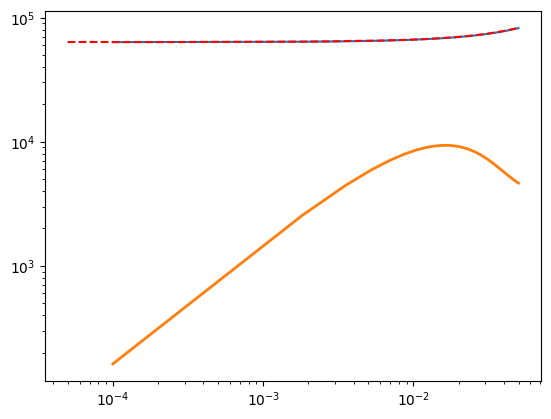

In [18]:
Ngg = np.loadtxt("Ngg.txt").T

import matplotlib.pyplot as plt
plt.loglog(Ks, results)
plt.plot(Ks, np.interp(Ks, kl, pl), lw = 2)
plt.plot(Ngg[0], Ngg[1], ls = "--", color = "red")

In [19]:
import sympy as sp
import sympy2jax
import pandas as pd

q1, q2, mu = sp.symbols('q1 q2 mu')
F = 0.5*(q2/q1+q1/q2)*mu
Ff = sp.lambdify([q1, q2, mu], F, 'numpy')


"""phiphi = fnl*b10
c01 = fnl*2*deltac*(b10-1)
c11 = fnl*(2./a1)*(deltac*(b20-2*(a1+a2)*(b10-1.))-a1**2.*(b10-1.))+2.*fnl*deltac*(b10-1.)
c02 = fnl**2*4*deltac*((deltac/a1**2.)*(b20-2.*(a1+a2)*(b10-1.))-2.*(b10-1.))"""

deltac = 1.42
# a1 = 1 in spherical collapse
a1 = 1.
# a2 = -17/21 in spherical collapse
a2 = -0.8095238095

cgs = {}
cgs["g"] = lambda b1, b2, bs2: b1+21/17*b2
cgs["s"] = lambda b1, b2, bs2: b1
cgs["t"] = lambda b1, b2, bs2: b1+7/2*bs2
cgs["x"] = lambda b1, b2, bs2: b1
cgs["n"] = lambda b1, b2, bs2: b1
cgs["phiphi"] = lambda b1, fnl: b1*fnl
cgs["c01"] = lambda b1, fnl: fnl*2*deltac*(b1-1.)
cgs["c11"] = lambda b1, b2, fnl: fnl*(2./a1)*(deltac*(b2-2*(a1+a2)*(b1-1.))-a1**2.*(b1-1.))+2.*fnl*deltac*(b1-1.)
cgs["c02"] = lambda b1, b2, fnl: fnl**2*4*deltac*((deltac/a1**2.)*(b2-2.*(a1+a2)*(b1-1.))-2.*(b1-1.))


Cg = {}
Cg["g"] = lambda b1A, b2A, b1B, bthetaA, bdeltathetaA, fX, bmrA, brA: (17/21*b1A+1/2*b2A)*b1B
Cg["s"] = lambda b1A, b2A, bs2A, b1B, b2B, bs2B: b1A*b1B
Cg["t"] = lambda b1A, b2A, bs2A, b1B, b2B, bs2B: (2/7*b1A+1/2*bs2A)*b1B
Cg["n"] = lambda b1A, b2A, bs2A, b1B, b2B, bs2B: 1*(b1A==b1B)
Cg["x"] = lambda b1A, epsilon, brB, bDB, bthetaB, H: b1A*epsilon*(17/6*brB-7/3*H*bthetaB-5/3*H*bDB)
Cg["phiphi"] = lambda b1A, b1B, fnl: b1A*fnl


b20_A = -0.3
b20_B = -0.3

bthetaB = 0.5
bthetaA = 0.3

brA = 1
brB = 2

epsilon = 1e-3
epsilon_2 = 10*epsilon

bs2f = lambda b10: -2./7.*(b10-1)

bs2_A = bs2f(b10_A)
bs2_B = bs2f(b10_B)

fX = 1
bmrA, bdeltathetaA = 0, 0
bmrB, bdeltathetaB = 0, 0

estimator_configs = {
        'g': {
            'F': 17./21.*q1/q1,
            'ca': Cg["g"](b1A = b10_A, b2A = b20_A, b1B = b10_B, bthetaA = 0, bdeltathetaA = 0, fX = 0, bmrA = 0, brA = 0), #AB
            'cb': Cg["g"](b1A = b10_B, b2A = b20_B, b1B = b10_A, bthetaA = 0, bdeltathetaA = 0, fX = 0, bmrA = 0, brA = 0) #BA
        },
        's': {
            'F': 0.5*(q2/q1+q1/q2)*mu, #NOTE: MU IS ALWAYS THE ANGLE BETWEEN Q1 AND Q2, BUT OFTEN IN THE CODE Q1 IS JUST K!
            'ca': Cg["s"](b1A = b10_A, b2A = 0, bs2A = 0, b1B = b10_B, b2B = 0, bs2B = 0),#b10,
            'cb': Cg["s"](b1A = b10_B, b2A = 0, bs2A = 0, b1B = b10_A, b2B = 0, bs2B = 0)#b10
        },
        't': {
            'F': (2./7.)*mu**2.-1./3.,
            'ca': Cg["s"](b1A = b10_A, b2A = 0, bs2A = bs2_A, b1B = b10_B, b2B = 0, bs2B = 0),
            'cb': Cg["s"](b1A = b10_B, b2A = 0, bs2A = bs2_B, b1B = b10_A, b2B = 0, bs2B = 0)
        },
        'x': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*(q2/q1+q1/q2)*mu,
            'ca': Cg["x"](b1A = b10_A, epsilon = epsilon, bthetaB = 0, brB = brB, bDB = 0, H = 0),
            'cb': Cg["x"](b1A = b10_B, epsilon = epsilon, bthetaB = 0, brB = brA, bDB = 0, H = 0)
        },
        'x2': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*(q2/q1+q1/q2)*mu,
            'ca': Cg["x"](b1A = b10_A, epsilon = epsilon_2, bthetaB = 0, brB = brB, bDB = 0, H = 0),
            'cb': Cg["x"](b1A = b10_B, epsilon = epsilon_2, bthetaB = 0, brB = brA, bDB = 0, H = 0)
        },
        'n': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*mu*q2/q1,
            'ca': Cg["n"](1, 0, 0, 1, 0, 0),
            'cb': Cg["n"](1, 0, 0, 0, 0, 0)
        }
    }

estimator_lam = {key: sp.lambdify([q1, q2, mu], estimator_configs[key]['F'], 'numpy') for key in estimator_configs}
estimator_lam_jax = {key: sympy2jax.SymbolicModule(estimator_configs[key]['F']) for key in estimator_configs}

In [20]:
Fj = sympy2jax.SymbolicModule(F)

In [21]:
def get_f(F, a, b):
  @jax.jit
  def f(k, K, mu):
    K_minus_k = jnp.sqrt(K**2+k**2-2*K*k*mu)
    mu1 = -mu
    mu2 = -(K**2 - k*K*mu) / (K*K_minus_k)
    result = 2*(a*F(q1 = K, q2 = k, mu = mu1)*P_linear(k)+b*F(q1 = K, q2 = K_minus_k, mu = mu2)*P_linear(K_minus_k))
    return result
  return f


f_jax = {key: get_f(estimator_lam_jax[key], estimator_configs[key]["ca"], estimator_configs[key]["cb"]) for key in estimator_lam_jax}

In [22]:
df = pd.read_pickle("quadratic_results.pkl")

In [23]:
Ks = df["K"]


keypairs = [("n", "n"), ("s", "n"), ("g", "n"), ("x", "n")]#, ("g", "g"), ("s", "s")]


estimator_keys = ["n", "g", "x", "s", "t", "x2"]
estimator_pairs = []
for i, alpha in enumerate(estimator_keys):
    for beta in estimator_keys[i:]:  # Only compute upper triangle (including diagonal)
        estimator_pairs.append((alpha, beta))

print(f"Calculating {len(estimator_pairs)} estimator pairs: {estimator_pairs}")

keypairs = estimator_pairs

out = {}

for keypair in keypairs:
  keyA, keyB = keypair
  @jax.jit
  def single_calculation(K):
      kmin, kmax = 0.051, 0.15

      def integrand(x):
          # Calculate N(K) = \int_{\vec{k}} [(P(k)+P(K-k))]^2/(PAA(k)*PBB(K-k))
          mu, k = x[:, 0], x[:, 1]
          phi_vol = 2*np.pi
          volume = phi_vol*k**2/(2*np.pi)**3
          K_minus_k = jnp.sqrt(K**2+k**2-2*K*k*mu)
          mask = (k>=kmin) & (k<=kmax)
          mask_2 = (K_minus_k>=kmin) & (K_minus_k<=kmax)
          mask *= mask_2
          fresultA = f_jax[keyA](k, K, mu)
          fresultB = f_jax[keyB](k, K, mu)
          return fresultA*fresultB/(2*P_AA(k)*P_BB(K_minus_k))*volume*mask

      Ndim = 2
      N = 10000**Ndim+1

      mc = MonteCarlo()
      result = mc.integrate(integrand, dim=Ndim, N=N,
                            integration_domain=[[-1, 1], [kmin, kmax]],
                            backend="jax")
      return result

  # Process in batches to avoid memory issues
  batch_size = 5  # Adjust based on your available memory
  results = []

  for i in range(0, len(Ks), batch_size):
      batch_Ks = jnp.array(Ks[i:i+batch_size])
      batch_results = jax.vmap(single_calculation)(batch_Ks)
      results.append(batch_results)
  results = np.concatenate(results)
  out[keypair] = results

  """# Vectorize the calculation over K values
  calculate_all = jax.vmap(single_calculation)
  results = calculate_all(jnp.array(Ks))
  results = np.array(results)

  out[keypair] = results"""

Calculating 21 estimator pairs: [('n', 'n'), ('n', 'g'), ('n', 'x'), ('n', 's'), ('n', 't'), ('n', 'x2'), ('g', 'g'), ('g', 'x'), ('g', 's'), ('g', 't'), ('g', 'x2'), ('x', 'x'), ('x', 's'), ('x', 't'), ('x', 'x2'), ('s', 's'), ('s', 't'), ('s', 'x2'), ('t', 't'), ('t', 'x2'), ('x2', 'x2')]


/usr/local/lib/python3.11/dist-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


In [24]:
Ks = df["K"]


#keypairs = [("n", "n"), ("s", "n"), ("g", "n"), ("x", "n")]#, ("g", "g"), ("s", "s")]


estimator_keys = ["n", "g", "x", "s", "t", "x2"]
estimator_pairs = []
for i, alpha in enumerate(estimator_keys):
    beta = alpha
    estimator_pairs.append((alpha, beta))

print(f"Calculating {len(estimator_pairs)} estimator pairs: {estimator_pairs}")

keypairs = estimator_pairs

out_cross_shot = {}

for keypair in keypairs:
  keyA, keyB = keypair
  @jax.jit
  def single_calculation(K):
      kmin, kmax = 0.051, 0.15

      def integrand(x):
          # Calculate N(K) = \int_{\vec{k}} [(P(k)+P(K-k))]^2/(PAA(k)*PBB(K-k))
          mu, k = x[:, 0], x[:, 1]
          phi_vol = 2*np.pi
          volume = phi_vol*k**2/(2*np.pi)**3
          K_minus_k = jnp.sqrt(K**2+k**2-2*K*k*mu)
          mask = (k>=kmin) & (k<=kmax)
          mask_2 = (K_minus_k>=kmin) & (K_minus_k<=kmax)
          mask *= mask_2
          fresultA = f_jax[keyA](k, K, mu)
          weightA = fresultA/(2*P_AA(k)*P_BB(K_minus_k))
          shotA = 1/nbar_A
          PS = P_AB(k)*shotA
          return weightA*PS*volume*mask

      Ndim = 2
      N = 10000**Ndim+1

      mc = MonteCarlo()
      result = mc.integrate(integrand, dim=Ndim, N=N,
                            integration_domain=[[-1, 1], [kmin, kmax]],
                            backend="jax")
      return result

  # Process in batches to avoid memory issues
  batch_size = 5  # Adjust based on your available memory
  results = []

  for i in range(0, len(Ks), batch_size):
      batch_Ks = jnp.array(Ks[i:i+batch_size])
      batch_results = jax.vmap(single_calculation)(batch_Ks)
      results.append(batch_results)
  results = np.concatenate(results)
  out_cross_shot[keypair] = results

  """# Vectorize the calculation over K values
  calculate_all = jax.vmap(single_calculation)
  results = calculate_all(jnp.array(Ks))
  results = np.array(results)

  out[keypair] = results"""

Calculating 6 estimator pairs: [('n', 'n'), ('g', 'g'), ('x', 'x'), ('s', 's'), ('t', 't'), ('x2', 'x2')]


In [25]:
import numpy as np
from scipy.optimize import curve_fit

# Define the model function
def inverse_square_model(K, a):
    return a / (K**2)

# Your data
Ks_np = np.array(Ks)
y_data = np.array(-out[("n", "x")]*out[("n", "n")]**-1.)

# Perform the curve fitting
params, covariance = curve_fit(inverse_square_model, Ks_np, y_data)

# Extract the optimal parameter
a_optimal = params[0]
print(f"Scipy curve_fit parameter: a = {a_optimal}")
print(f"Parameter std error: {np.sqrt(covariance[0,0])}")

# Calculate fitted values (can convert back to JAX array if needed)
y_fit = a_optimal / Ks_np**2
y_fit_jax = a_optimal / jnp.array(Ks)**2

Scipy curve_fit parameter: a = -3.2741081176032575e-08
Parameter std error: 1.0276027541626552e-08


[('n', 'n')]


<ipython-input-26-557c86c83d33>:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = get_cmap('tab10')


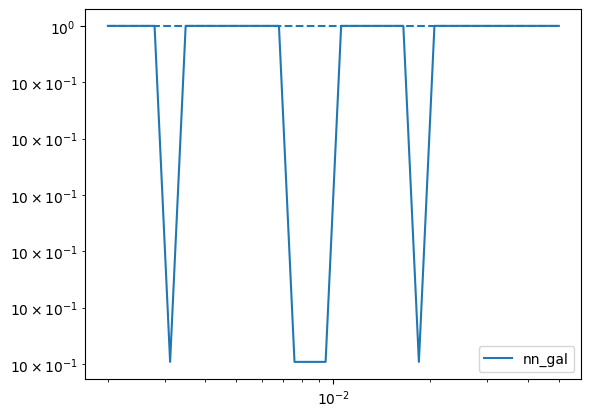

In [26]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
colors = get_cmap('tab10')

#plt.loglog(Ks, np.interp(Ks, kl, pl), lw = 2)

keypairs_plot = [keypair for keypair in keypairs if keypair[0] == "n"]
print(keypairs_plot)
for i, keypair in enumerate(keypairs_plot):

  keyA, keyB = keypair
  estimator_pair = f"{keyA}{keyB}"
  tr1 = "gal"
  tr2 = ""
  key = f"{estimator_pair}_{tr1}{tr2}"

  if estimator_pair == "nn":
    norm = out[keypair]**-1.
    Nxx = df[key]**-1.

  p = plt.loglog(Ks, abs(out[keypair]*norm), color = colors(i), label = key)
  plt.plot(df["K"], abs(df[key]*Nxx), ls = "--", color = colors(i))

plt.plot(Ks, y_fit_jax, color = "black", marker = "o", alpha = 0.4)
plt.legend()
plt.xscale("log")

Font loaded: Lexend Deca
nn
ns
ng
nt
nx
nx2


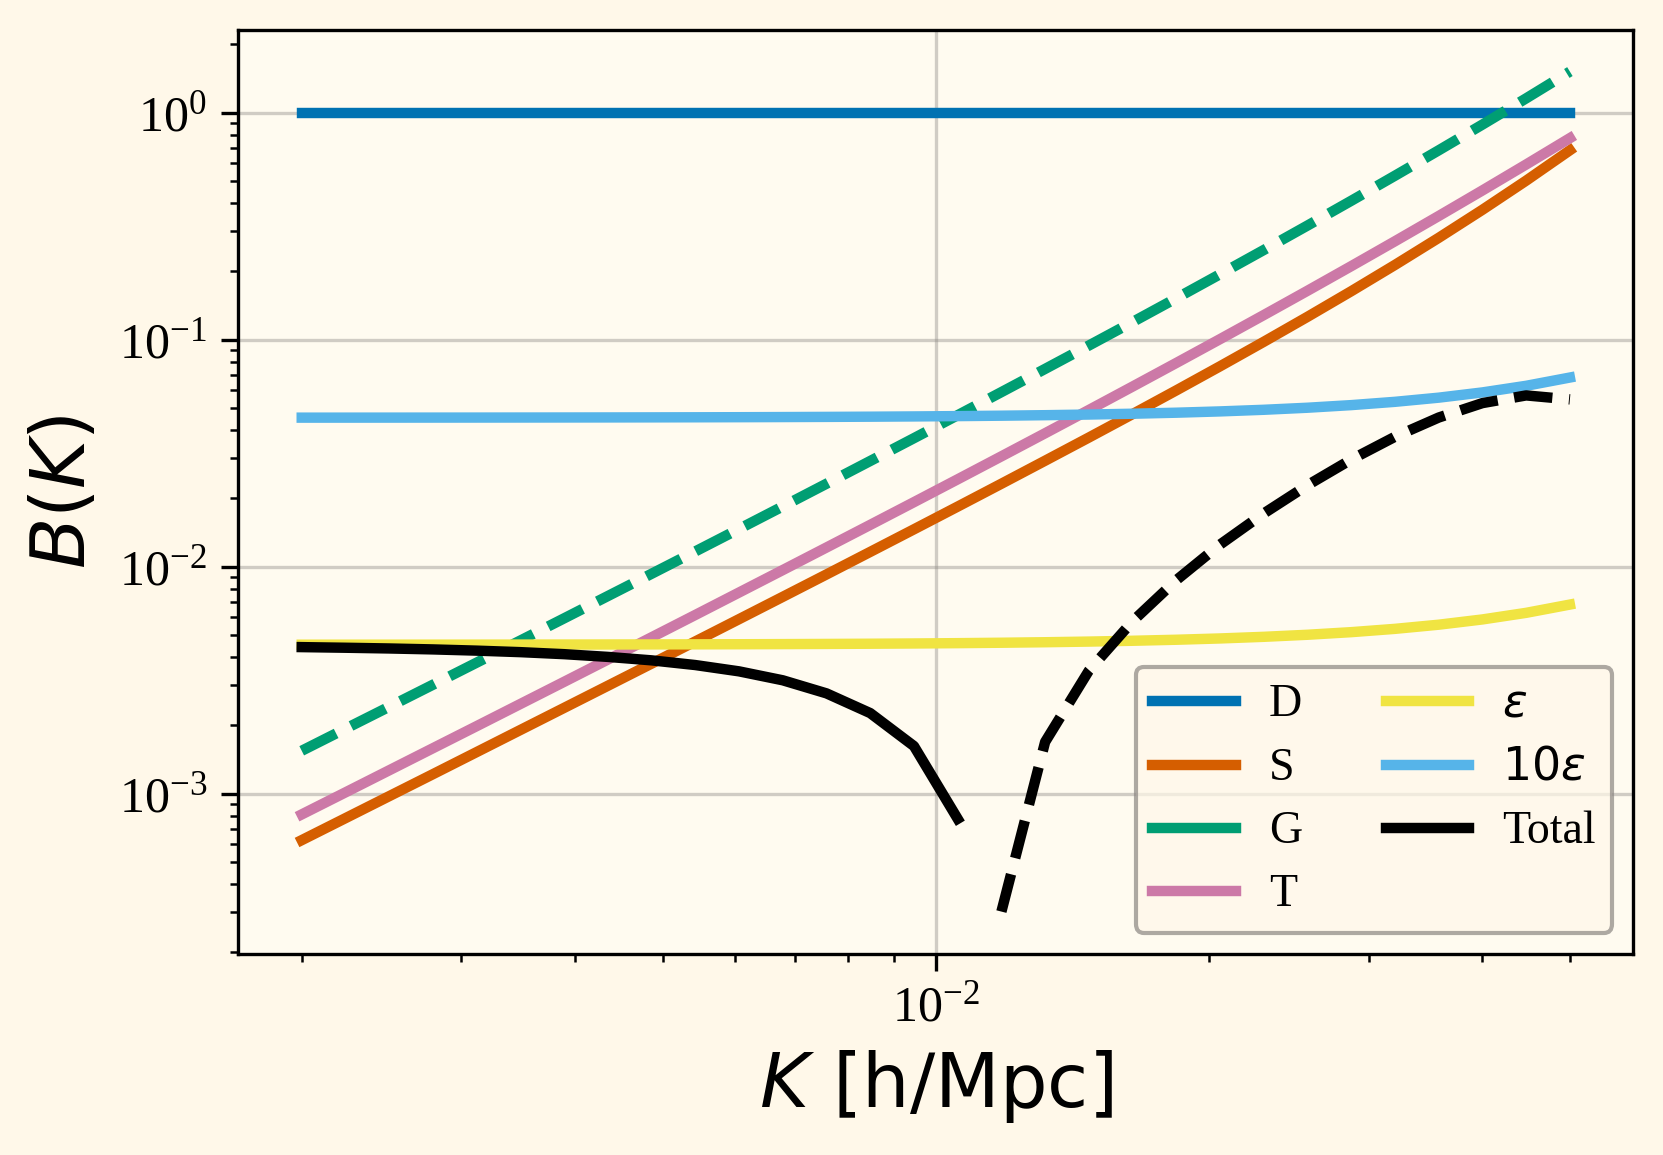

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator
import matplotlib.font_manager as fm
from matplotlib.cm import get_cmap

font_path = "LexendDeca-VariableFont_wght.ttf"
font_properties = fm.FontProperties(fname=font_path)
print(f"Font loaded: {font_properties.get_name()}")


# Register Liberation Serif fonts explicitly
font_path_regular = '/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf'
# Create font properties objects
font_regular = fm.FontProperties(fname=font_path_regular)

# Create figure with more traditional academic styling
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
fig.patch.set_facecolor('#FFF8E9')  # Warmer cream color for old-style look
ax.set_facecolor('#FFFBF0')  # Slightly lighter cream for plot area

# Adjust line widths for a more classic look
ax.spines['top'].set_linewidth(0.8)
ax.spines['right'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_linewidth(0.8)
ax.tick_params(width=0.8, length=4, which='major')
ax.tick_params(width=0.6, length=2, which='minor')

# Use colorblind-friendly colors instead of the default tab10
# This maps the tab10 colormap to a colorblind-friendly palette
colorblind_palette = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#F0E442',
                      '#56B4E9', '#E69F00', '#000000']

# Create a custom colormap function that maps tab10 indices to our colorblind palette
def colorblind_colormap(i):
    return colorblind_palette[i % len(colorblind_palette)]

# Your original plotting code, integrated with the styling
# --------------------------------------------------------

# Assuming these variables are defined in your context:
# Ks, keypairs, out, norm, y_fit_jax, df (if needed)

key_selected = "n"

names = {"n": "D", f"x": r"$\epsilon$", f"s": "S", f"t": "T", "g": "G", f"x2": r"$10\epsilon$"}

estimators_all = ["s", "g", "t", "n", "x", "x2"]
# Plot each keypair
keypairs_plot = [(key_selected, key_selected)]+[(key_selected, c) for c in estimators_all if c != key_selected]

somma = 0
derivatives = {}
epsilons = {"x": epsilon, "x2": epsilon_2}

for i, keypair in enumerate(keypairs_plot):
    keyA, keyB = keypair
    estimator_pair = f"{keyA}{keyB}"
    tr1 = "gal"
    tr2 = ""
    key = f"{estimator_pair}_{tr1}{tr2}"
    key_rev = f"{keyB}{keyA}_{tr1}{tr2}"

    if estimator_pair in ["nn", f"{key_selected}{key_selected}"]:
        norm = out[keypair]**-1.
        Nxx = df[key]**-1.

    # Use colorblind-friendly colors and increase line width for better visibility
    try:
      value = out[keypair]*norm
    except:
      value = out[(keypair[1], keypair[0])]*norm

    print(estimator_pair)
    if estimator_pair not in ["nn", "nx2"]: #this is the only one that it is not a proper full effect
      somma += value
    if ("x" in estimator_pair) and (key_selected != "x"):
      derivatives[estimator_pair] = value/epsilons[keyB]

    #try:
    #  nterm = df[key_rev]
    #except:
    #  nterm = df[key]

    #Nxx = 1.
    #ax.plot(Ks, nterm*Nxx, ls = ":", label = names[estimator_pair])
    #value = value/norm

    name = names[keyB]

    mask = value > 0
    p = ax.loglog(Ks[mask], value[mask],
                 color=colorblind_colormap(i),
                 linewidth=2.5,
                 label=name, ls = "-")
    p = ax.loglog(Ks[~mask], -value[~mask],
                 color=colorblind_colormap(i),
                 linewidth=2.5, ls = "--")

    # Uncomment if you want to include this part of your original code
    # plt.plot(df["K"], abs(df[key]*Nxx), ls="--", color=colorblind_colormap(i))

mask = somma >= 0
p = ax.loglog(Ks[mask], somma[mask],
                 color="black",
                 linewidth=2.5,
                 label="Total", ls = "-")
p = ax.loglog(Ks[~mask], -somma[~mask],
                 color="black",
                 linewidth=2.5, ls = "--")

# Plot the fit with enhanced visibility for publication
"""ax.plot(Ks, abs(y_fit_jax), color="black", marker="o",
       alpha=0.6,  # Slightly higher alpha for better visibility
       label= r"$\frac{1}{K^2}$ fit",
       markersize=6,  # Larger markers
       markeredgecolor='white',  # White edge for contrast
       markeredgewidth=0.5, ls = "")"""

#, fontproperties=font_properties
# Set labels with custom fonts
label_kwargs = {'fontproperties': font_properties, 'fontsize': 18}
title_kwargs = {'fontproperties': font_properties, 'fontsize': 22, 'pad': 10}
ax.set_xlabel(r'$K \ \mathrm{[h/Mpc]}$', **label_kwargs)
ax.set_ylabel(r'$B(K)$', **label_kwargs)

# Ensure log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Add grid with classic styling
ax.grid(True, linestyle='-', alpha=0.4, color='#8B8682')


ax.tick_params(axis='both', which='major', labelsize=14)

# Add minor ticks appropriate for log scales
#ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
#ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))

legend = ax.legend(ncol = 2, framealpha=0.7, edgecolor='#8B8682', loc='best',
                  fancybox=True, frameon=True, facecolor='#FFF8E9')

# Apply custom font to legend text
for text in legend.get_texts():
    text.set_fontproperties(font_regular)
    text.set_fontsize(11)

# Apply custom font to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font_regular)
    label.set_fontsize(12)

# Add a subtle watermark
#fig.text(0.98, 0.01, "Liberation Serif", fontproperties=font_italic, fontsize=8,
#         color='#8B8682', alpha=0.7, ha='right', va='bottom')

# Tight layout for better use of space
#fig.tight_layout()

plt.savefig("bias.pdf", dpi = 300)

# Show the plot
plt.show()

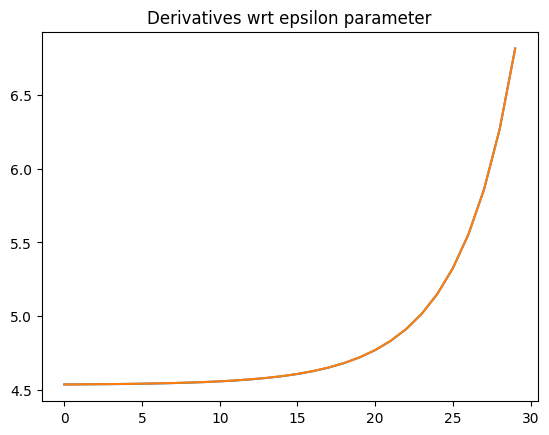

In [33]:
plt.title("Derivatives wrt epsilon parameter")
plt.plot(derivatives["nx"])
plt.plot(derivatives["nx2"])

keypairs_plot [('n', 'n'), ('n', 's'), ('n', 'g'), ('n', 't'), ('n', 'x'), ('n', 'x2')]


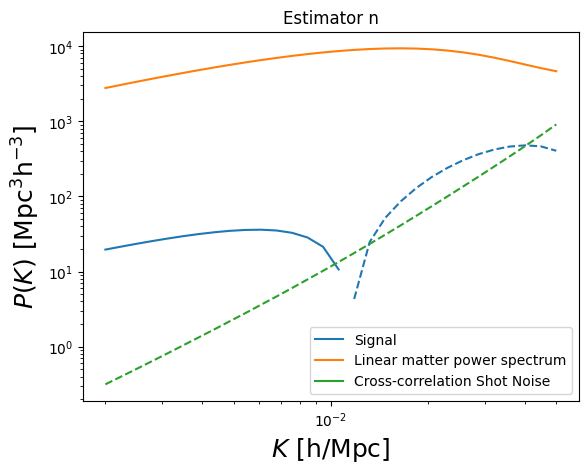

In [34]:
print("keypairs_plot", keypairs_plot)

plt.title(f"Estimator {key_selected}")

Ks = jnp.array(Ks)
signal = b10_A*somma*P_linear(Ks) #this is the cross-correlation between the estimator and the galaxy A

norm = out[(key_selected, key_selected)]**-1

mask = signal>0
p = plt.plot(Ks[~mask], -signal[~mask], ls = "--")
plt.plot(Ks[mask], signal[mask], label = "Signal", ls = "-", color = p[0].get_color())

plt.plot(Ks, P_linear(Ks), label = "Linear matter power spectrum")

noise = norm*out_cross_shot[(key_selected, key_selected)]
mask = noise > 0
p = plt.loglog(Ks[~mask], -noise[~mask], ls = "--")
plt.loglog(Ks[mask], noise[mask], label = "Cross-correlation Shot Noise", ls = "-", color = p[0].get_color())

plt.xlabel(r'$K \ \mathrm{[h/Mpc]}$', **label_kwargs)
plt.ylabel(r'$P(K) \ \mathrm{[Mpc^{3}h^{-3}]}$', **label_kwargs)


plt.legend()
plt.savefig("cross_shot.pdf", dpi = 300)

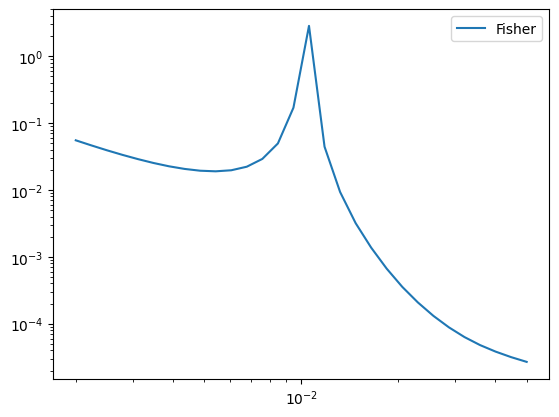

In [35]:
totalps = signal+noise

#plt.plot(Ks, signal/totalps)

plt.loglog(Ks, (derivatives[f"{key_selected}x"]/totalps)**2, label = "Fisher")
plt.legend()

In [36]:
Fisher = (derivatives[f"{key_selected}x"]/totalps)**2
# Survey volume in (Gpc/h)^3
volume = 30.
volume *= 10**9
#integrate fisher from Kmin to Kmax, and mu = -1 to mu = +1
kmin, kmax = 0.051, 0.15
mu_min, mu_max = -1, 1

@jax.jit
def fisher_interp(x):
  return jnp.interp(x, Ks, Fisher)

@jax.jit
def integrand_fisher(x):
  return fisher_interp(x)

result_fisher = mc.integrate(integrand_fisher, dim=1, N=1000000, integration_domain=[[Ks.min(), Ks.max()]], backend="jax")
result_fisher *= volume/(2*np.pi)**2*2

error_bar = result_fisher**-1.
error_bar


/usr/local/lib/python3.11/dist-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


Array(1.7356699e-07, dtype=float32)